<a href="https://colab.research.google.com/github/Moukthika-y/Foundations-of-Data-Science-Lab/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment - 01

1.   EDA
2.   Identify various Nominal, Numeric, Binary attributes.
3.   For any two identified Nominal attributes measure data dissimilarity
4.   For any two identified Numeric attributes measure data dissimilarity








In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Read the data set
df = pd.read_csv("/content/Titanic-Dataset (1).csv")
print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

First 5 Records
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

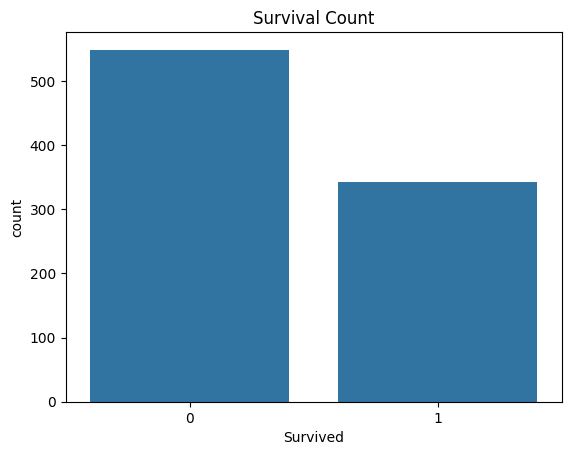

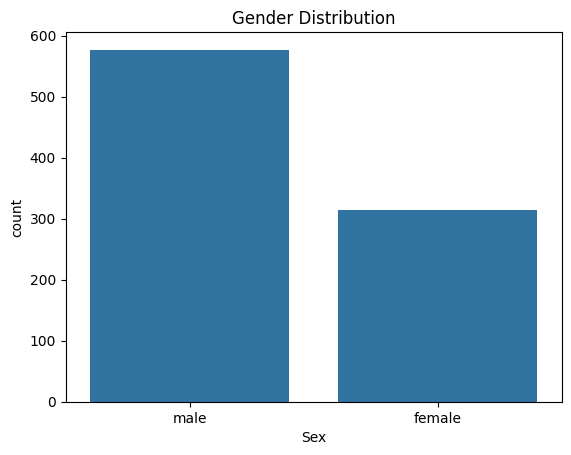

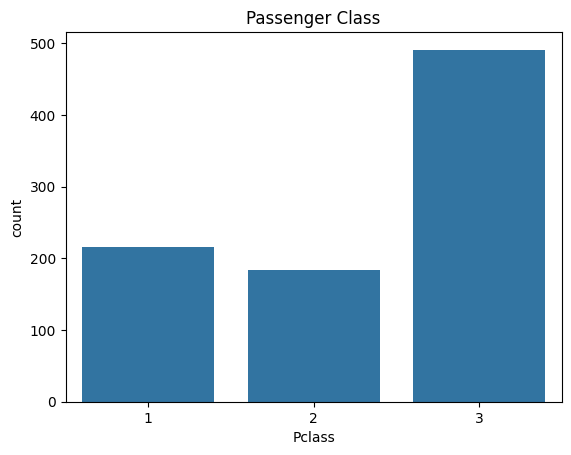

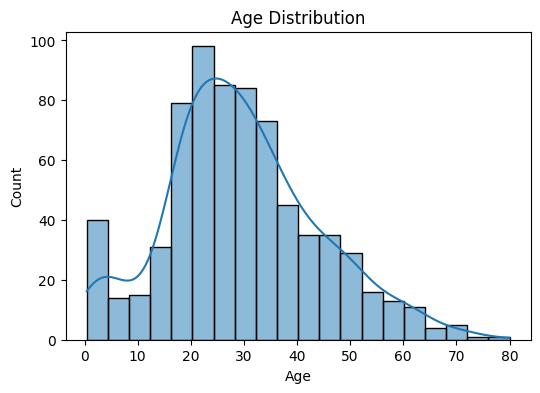

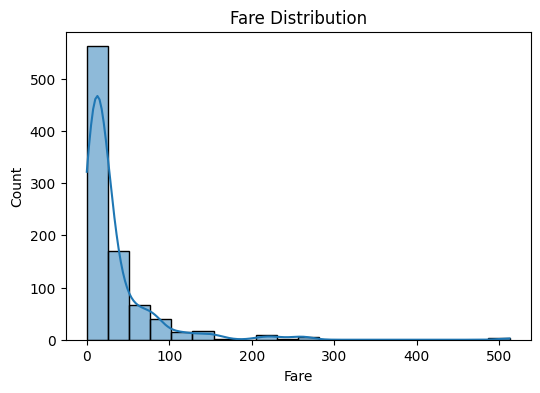

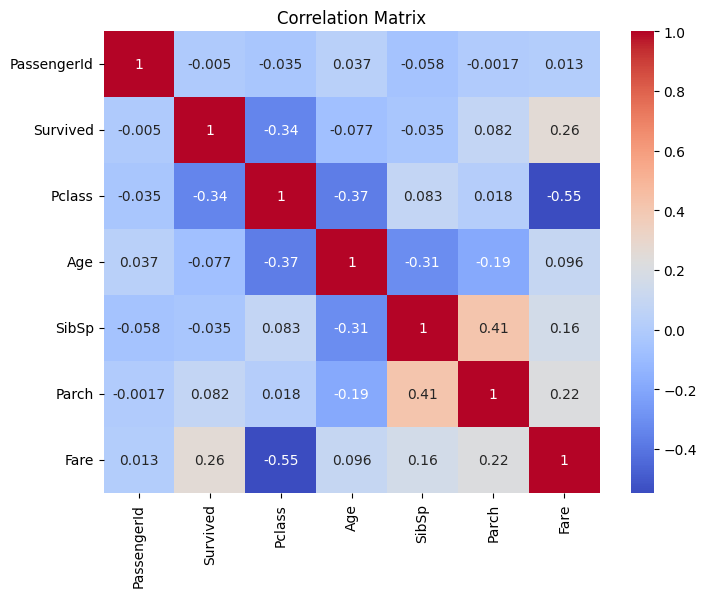

In [ ]:
# Exploratory Data Analysis (EDA)
# Survival Count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Gender Count
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

# Passenger Class
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=20, kde=True)
plt.title("Fare Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


In [ ]:
print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64','float64']).columns
print(numeric)

print("\nNominal Attributes")
nominal = []

for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique(dropna=True) > 2:
        nominal.append(col)

print(nominal)

print("\nBinary Attributes")
binary = []

for col in df.columns:
    if df[col].nunique(dropna=True) == 2:
        binary.append(col)

print(binary)



Numeric Attributes
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Nominal Attributes
['Sex', 'Embarked']

Binary Attributes
['Survived']


In [ ]:
# Dissimilarity
sex = df['Sex']
embarked = df['Embarked']

count = 0
total = 0

for s,e in zip(sex,embarked):

    if pd.isna(s) or pd.isna(e):
        continue

    total += 1

    if s != e:
        count += 1

dissimilarity = count/total

print("\nNominal Attribute Dissimilarity")
print("Sex vs Embarked =", dissimilarity)

similarity = 1 - dissimilarity

print("Nominal Attribute Similarity =", similarity)



Nominal Attribute Dissimilarity
Sex vs Embarked = 1.0
Nominal Attribute Similarity = 0.0


In [ ]:
#Numeric attributes dissimilarity
temp = df[['Age','Fare']].dropna()

age = temp.iloc[0]['Age']
fare = temp.iloc[0]['Fare']

age2 = temp.iloc[1]['Age']
fare2 = temp.iloc[1]['Fare']

distance = np.sqrt((age-age2)**2 + (fare-fare2)**2)

print("\nEuclidean Distance")
print(distance)





Euclidean Distance
66.00199624928021


# Experiment - 03


1.   Preprocessing




In [ ]:
print("Missing values\n")
print(df.isna().sum())

Missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Fill Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin
df = df.drop('Cabin', axis=1)

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


# Experiment - 05



1.   Apply various measures of dispersion.
2.   Plot graphs to study the shape of data distribution.



In [ ]:
age = df['Age']

# Range
print("Range = ",age.max()-age.min())

# Standard deviation
print("Standard deviation = ",age.std())

# Variance
print("Variance = ",age.var())

Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)

# IQR
IQR = Q1-Q3
print("IQR: ",IQR)

Range =  79.58
Standard deviation =  13.002015226002884
Variance =  169.05239993721085
IQR:  -13.0


<function matplotlib.pyplot.show(close=None, block=None)>

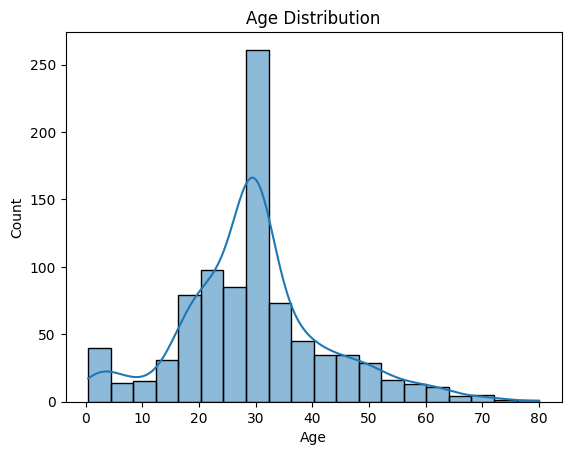

In [ ]:
sns.histplot(df['Age'],bins = 20,kde=True)
plt.title("Age Distribution")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

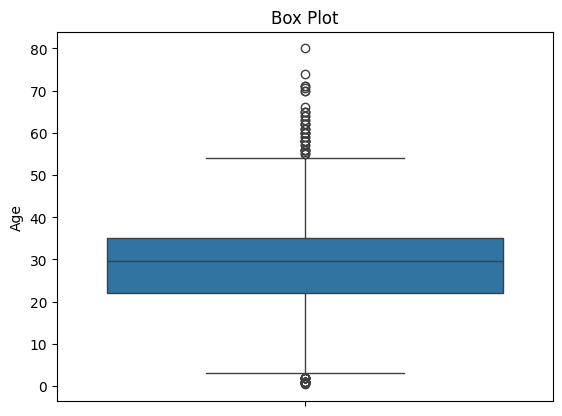

In [ ]:
sns.boxplot(y=df['Age'])
plt.title("Box Plot")
plt.show